In [1]:
import os
import xarray as xr
import numpy as np
import pandas as pd
import functools
import matplotlib.pyplot as plt
import dask
from dask_jobqueue import PBSCluster
from dask.distributed import Client

import above_library.processing as proc

In [2]:
# Setup PBSCluster
cluster = PBSCluster(
    cores=1,                                                   # The number of cores you want
    memory='25GB',                                             # Amount of memory
    processes=1,                                               # How many processes
    queue='casper',                                            # The type of queue to utilize
    local_directory='/glade/work/afoster',                     # Use your local directory
    resource_spec='select=1:ncpus=1:mem=25GB',                 # Specify resources
    log_directory='/glade/derecho/scratch/afoster/dask_logs',  # log directory
    account='P08010000',                                       # Input your project ID here
    walltime='04:00:00',                                       # Amount of wall time
    interface='ext')

In [3]:
cluster.scale(30)
dask.config.set({
    'distributed.dashboard.link': 'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
})
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/afoster/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/afoster/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.191:40089,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/afoster/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [4]:
def get_ds(case_name):
    hist_dir = f'/glade/derecho/scratch/afoster/archive/{case_name}/lnd/hist'
    files = proc.get_files(hist_dir)
    ds = xr.open_mfdataset(
        files,
        combine="nested",
        concat_dim="time",
        preprocess=functools.partial(proc.preprocess, data_vars=hist_vars),
        parallel=True,
        decode_times=True,
    )
    return ds.isel(lndgrid=0)
    
def calc_gpp(ds):
    months = ds["time.daysinmonth"]
    return 86400 * (months * ds.FATES_GPP).groupby("time.year").sum()

def average_mortality(da):
    return (da / 0.0001).groupby("time.year").mean().compute()

def grab_slice(ds, year):
    storec = ds.FATES_STOREC_PF.sel(fates_levpft=2).isel(time=slice(year*12, year*12+12))
    vegc = ds.FATES_VEGC.isel(time=slice(year*12, year*12+12))
    gpp = ds.FATES_GPP.isel(time=slice(year*12, year*12+12))

    return gpp, vegc, storec

def grab_slice(ds, var, year):
    return ds[var].isel(time=slice(year*12, year*12+12))

def get_mortality(ds):

    nplant = ds.FATES_NPLANT_SZ/ 0.0001
    cstarv_mort = ds.FATES_MORTALITY_CSTARV_SZ/ 0.0001
    hydraulic_mort = ds.FATES_MORTALITY_FREEZING_SZ/ 0.0001
    freezing_mort = ds.FATES_MORTALITY_HYDRAULIC_SZ/ 0.0001
    background_mort = ds.FATES_MORTALITY_BACKGROUND_SZ/ 0.0001
    senesce_mort = ds.FATES_MORTALITY_SENESCENCE_SZ/ 0.0001
    impact_mort = ds.FATES_MORTALITY_IMPACT_SZ/ 0.0001
    termination_mort = ds.FATES_MORTALITY_TERMINATION_SZ/ 0.0001
    total_mort = cstarv_mort + hydraulic_mort + freezing_mort + background_mort + senesce_mort + impact_mort + termination_mort

    ds_out = xr.merge([nplant.to_dataset(name='nplant'),
                        total_mort.to_dataset(name = 'total'),
                        cstarv_mort.to_dataset(name = 'cstarv'),
                        hydraulic_mort.to_dataset(name = 'hydraulic'),
                        freezing_mort.to_dataset(name = 'freezing'),
                        background_mort.to_dataset(name = 'background'),
                        senesce_mort.to_dataset(name = 'senesce'),
                        impact_mort.to_dataset(name = 'impact'),
                        termination_mort.to_dataset(name = 'termination')])

    return ds_out

def get_annual_mortality(ds):

    nplant = (ds.FATES_NPLANT_SZ / 0.0001).groupby("time.year").mean().compute()
    cstarv_mort = average_mortality(ds.FATES_MORTALITY_CSTARV_SZ)
    hydraulic_mort = average_mortality(ds.FATES_MORTALITY_FREEZING_SZ)
    freezing_mort = average_mortality(ds.FATES_MORTALITY_HYDRAULIC_SZ)
    background_mort = average_mortality(ds.FATES_MORTALITY_BACKGROUND_SZ)
    senesce_mort = average_mortality(ds.FATES_MORTALITY_SENESCENCE_SZ)
    impact_mort = average_mortality(ds.FATES_MORTALITY_IMPACT_SZ)
    termination_mort = average_mortality(ds.FATES_MORTALITY_TERMINATION_SZ)
    total_mort = cstarv_mort + hydraulic_mort + freezing_mort + background_mort + senesce_mort + impact_mort + termination_mort

    ds_out = xr.merge([nplant.to_dataset(name='nplant'),
                        total_mort.to_dataset(name = 'total'),
                        cstarv_mort.to_dataset(name = 'cstarv'),
                        hydraulic_mort.to_dataset(name = 'hydraulic'),
                        freezing_mort.to_dataset(name = 'freezing'),
                        background_mort.to_dataset(name = 'background'),
                        senesce_mort.to_dataset(name = 'senesce'),
                        impact_mort.to_dataset(name = 'impact'),
                        termination_mort.to_dataset(name = 'termination')])

    return ds_out

def plot_mortality(ds, scls):

    ds_sub = ds.sel(fates_levscls=scls)
    
    fig = plt.figure()
    ax = plt.subplot(111)
    ax.plot(ds_sub.year, ds_sub.total, label='total', c='k')
    ax.plot(ds_sub.year, ds_sub.hydraulic, label='hydraulic', c='blue')
    ax.plot(ds_sub.year, ds_sub.cstarv, label='carbon starvation', c='green')
    ax.plot(ds_sub.year, ds_sub.freezing, label='freezing', c='cyan')
    ax.plot(ds_sub.year, ds_sub.background, label='background', c='gray')
    ax.plot(ds_sub.year, ds_sub.senesce, label='senese', c='red')
    ax.plot(ds_sub.year, ds_sub.impact, label='impact', c='orange')
    ax.plot(ds_sub.year, ds_sub.termination, label='termination', c='purple')
    ax.legend(bbox_to_anchor=(1.1, 1.05))
    plt.tight_layout()


def plot_prop_mortality(ds_mort, scls):

    ds_sub = ds_mort.isel(fates_levscls=scls)
    size_classes = ds_mort.fates_levscls.values
    
    fig = plt.figure()
    ax = plt.subplot(111)
    ax.plot(ds_sub.year, ds_sub.total/ds_sub.nplant, label='total', c='k')
    ax.plot(ds_sub.year, ds_sub.hydraulic/ds_sub.nplant, label='hydraulic', c='blue')
    ax.plot(ds_sub.year, ds_sub.cstarv/ds_sub.nplant, label='carbon starvation', c='green')
    ax.plot(ds_sub.year, ds_sub.freezing/ds_sub.nplant, label='freezing', c='cyan')
    ax.plot(ds_sub.year, ds_sub.background/ds_sub.nplant, label='background', c='gray')
    ax.plot(ds_sub.year, ds_sub.senesce/ds_sub.nplant, label='senese', c='red')
    ax.plot(ds_sub.year, ds_sub.impact/ds_sub.nplant, label='impact', c='orange')
    ax.plot(ds_sub.year, ds_sub.termination/ds_sub.nplant, label='termination', c='purple')
    ax.legend(bbox_to_anchor=(1.0, 1.05))
    
    plt.title(f'Mortality for {size_classes[scls]} - {size_classes[scls+1]} cm trees')
    plt.tight_layout()

def get_dbh_increment(ds):
    dbh_increment_canopy = (ds.FATES_DDBH_CANOPY_SZ * 100.0) / ds.FATES_NPLANT_CANOPY_SZ
    dbh_increment_ustory = (ds.FATES_DDBH_USTORY_SZ * 100.0) / ds.FATES_NPLANT_USTORY_SZ

    annual_growth_rate_canopy = dbh_increment_canopy.groupby('time.year').mean()
    annual_growth_rate_ustory = dbh_increment_ustory.groupby('time.year').mean()

    out = xr.merge([annual_growth_rate_canopy.to_dataset(name='ddbh_canopy'),
                    annual_growth_rate_ustory.to_dataset(name='ddbh_ustory')])
    return out

In [5]:
hist_vars = ['FATES_GPP', 'FATES_NPLANT_SZ', 'FATES_VEGC',
             'FATES_NPLANT_CANOPY_SZ', 'FATES_NPLANT_USTORY_SZ',
             'FATES_MORTALITY_CSTARV_SZ', 'FATES_STOREC_PF',
             'FATES_RECRUITMENT_PF', 'FATES_MORTALITY_PF',
             'FATES_MORTALITY_BACKGROUND_SZ',
             'FATES_MORTALITY_FREEZING_SZ',
             'FATES_MORTALITY_HYDRAULIC_SZ',
             'FATES_MORTALITY_IMPACT_SZ',
             'FATES_MORTALITY_SENESCENCE_SZ',
             'FATES_MORTALITY_TERMINATION_SZ',
             'FATES_DDBH_CANOPY_SZ', 'FATES_DDBH_USTORY_SZ',
             'TSA', 'SNOW_DEPTH', 'BTRANMN']

In [6]:
ds_orig = get_ds("NWT_singlept_ZF14-207_")
ds_leaf = get_ds("NWT_singlept_ZF14-207_leaf_biome")
ds_height = get_ds("NWT_singlept_ZF14-207_height")
ds_mort = get_ds("NWT_singlept_ZF14-207_bmort_low")
ds_agb = get_ds("NWT_singlept_ZF14-207_agb")
ds_ca = get_ds("NWT_singlept_ZF14-207_crown_area3")
ds_sa = get_ds("NWT_singlept_ZF14-207_la_per_sa")

In [7]:
ds_sa = get_ds("NWT_singlept_ZF14-207_la_per_sa")

In [8]:
vegC_orig = (ds_orig.FATES_VEGC / 0.0001 * 0.001).groupby("time.year").mean().compute()
vegC_leaf = (ds_leaf.FATES_VEGC / 0.0001 * 0.001).groupby("time.year").mean().compute()
vegC_height = (ds_height.FATES_VEGC / 0.0001 * 0.001).groupby("time.year").mean().compute()
vegC_mort = (ds_mort.FATES_VEGC / 0.0001 * 0.001).groupby("time.year").mean().compute()
vegC_agb = (ds_agb.FATES_VEGC / 0.0001 * 0.001).groupby("time.year").mean().compute()
vegC_ca = (ds_ca.FATES_VEGC / 0.0001 * 0.001).groupby("time.year").mean().compute()
vegC_sa = (ds_sa.FATES_VEGC / 0.0001 * 0.001).groupby("time.year").mean().compute()

In [9]:
nplant_orig = (ds_orig.FATES_NPLANT_SZ / 0.0001).groupby("time.year").mean().compute()
nplant_leaf = (ds_leaf.FATES_NPLANT_SZ / 0.0001).groupby("time.year").mean().compute()
nplant_height = (ds_height.FATES_NPLANT_SZ / 0.0001).groupby("time.year").mean().compute()
nplant_mort = (ds_mort.FATES_NPLANT_SZ / 0.0001).groupby("time.year").mean().compute()
nplant_agb = (ds_agb.FATES_NPLANT_SZ / 0.0001).groupby("time.year").mean().compute()
nplant_ca = (ds_ca.FATES_NPLANT_SZ / 0.0001).groupby("time.year").mean().compute()
nplant_sa = (ds_sa.FATES_NPLANT_SZ / 0.0001).groupby("time.year").mean().compute()

gpp_orig = calc_gpp(ds_orig).compute()
gpp_leaf = calc_gpp(ds_leaf).compute()
gpp_height = calc_gpp(ds_height).compute()
gpp_mort = calc_gpp(ds_mort).compute()
gpp_agb = calc_gpp(ds_agb).compute()
gpp_ca = calc_gpp(ds_ca).compute()
gpp_sa = calc_gpp(ds_sa).compute()

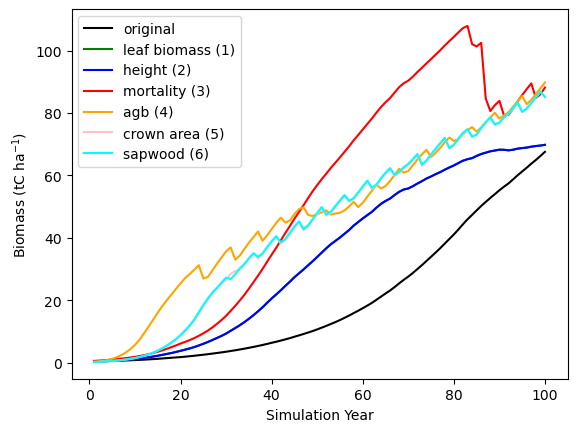

In [41]:
plt.plot(vegC_orig.year, vegC_orig.values, c='black', label='original')
plt.plot(vegC_leaf.year, vegC_leaf.values, c='green', label='leaf biomass (1)')
plt.plot(vegC_height.year, vegC_height.values, c='blue', label='height (2)')
plt.plot(vegC_mort.year, vegC_mort.values, c='red', label='mortality (3)')
plt.plot(vegC_agb.year, vegC_agb.values, c='orange', label='agb (4)')
plt.plot(vegC_ca.year, vegC_ca.values, c='pink', label='crown area (5)')
plt.plot(vegC_sa.year, vegC_sa.values, c='cyan', label='sapwood (6)')
plt.xlabel('Simulation Year')
plt.ylabel("Biomass (tC ha$^{-1}$)")
plt.legend()
plt.savefig("../figures/biomass_updated.png")

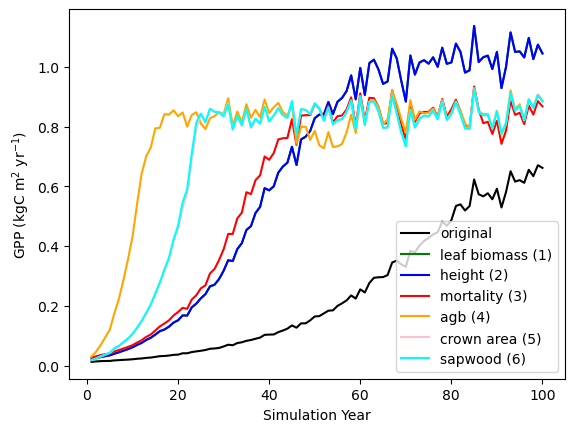

In [42]:
plt.plot(gpp_orig.year, gpp_orig.values, c='black', label='original')
plt.plot(gpp_leaf.year, gpp_leaf.values, c='green', label='leaf biomass (1)')
plt.plot(gpp_height.year, gpp_height.values, c='blue', label='height (2)')
plt.plot(gpp_mort.year, gpp_mort.values, c='red', label='mortality (3)')
plt.plot(gpp_agb.year, gpp_agb.values, c='orange', label='agb (4)')
plt.plot(gpp_ca.year, gpp_ca.values, c='pink', label='crown area (5)')
plt.plot(gpp_sa.year, gpp_sa.values, c='cyan', label='sapwood (6)')
plt.xlabel('Simulation Year')
plt.ylabel("GPP (kgC m$^2$ yr$^{-1}$)")
plt.legend()
plt.savefig("../figures/GPP_updated.png")

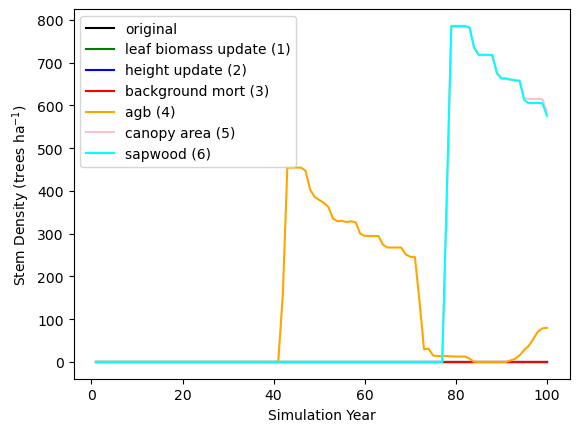

In [43]:
scls=20
plt.plot(nplant_orig.year, nplant_orig.sel(fates_levscls=scls).values, c='black', label='original')
plt.plot(nplant_leaf.year, nplant_leaf.sel(fates_levscls=scls).values, c='green', label='leaf biomass update (1)')
plt.plot(nplant_height.year, nplant_height.sel(fates_levscls=scls).values, c='blue', label='height update (2)')
plt.plot(nplant_mort.year, nplant_mort.sel(fates_levscls=scls).values, c='red', label='background mort (3)')
plt.plot(nplant_agb.year, nplant_agb.sel(fates_levscls=scls).values, c='orange', label='agb (4)')
plt.plot(nplant_ca.year, nplant_ca.sel(fates_levscls=scls).values, c='pink', label='canopy area (5)')
plt.plot(nplant_sa.year, nplant_sa.sel(fates_levscls=scls).values, c='cyan', label='sapwood (6)')
plt.xlabel('Simulation Year')
plt.ylabel("Stem Density (trees ha$^{-1}$)")
plt.legend()
plt.savefig("../figures/nplant_updated.png")

In [16]:
dbh_incr_orig = get_dbh_increment(ds_orig)
dbh_incr_leaf = get_dbh_increment(ds_leaf)
dbh_incr_agb = get_dbh_increment(ds_agb)
dbh_incr_ca = get_dbh_increment(ds_ca)
ddbh = dbh_incr_agb.ddbh_canopy.mean(dim='year').compute()

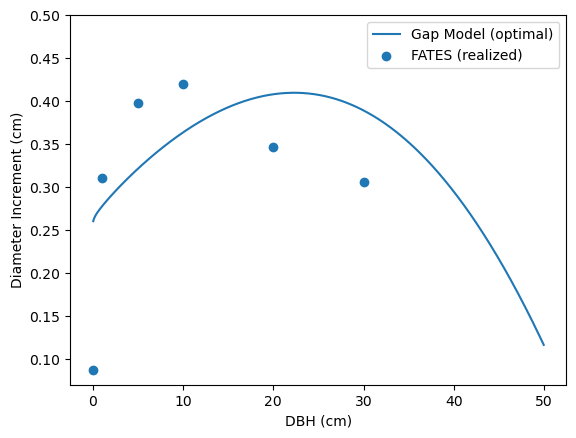

In [44]:
p1 = 34.69419
p2 = 0.98876
p3 = 24.06581
D = np.arange(0.05, 50, 0.05)
ht = (p1*D**p2)/(p3+D**p2)


s = 1.1
hmax = 25.0 
dmax = 52.0 
g = 1.06 
temp = s*np.exp(-s*D/(hmax - 1.3))*D
gap_growth = g*D*(1.0 - D*ht/dmax/hmax)/(2.0*ht + temp)

delta_ht = hmax - 1.3
forska_ht = 1.3 + delta_ht*(1.0 - np.exp(-(s*D/delta_ht)))

plt.plot(D, gap_growth, label='Gap Model (optimal)')
plt.scatter(ds_agb.fates_levscls, ddbh, label='FATES (realized)')
plt.xlabel("DBH (cm)")
plt.ylabel("Diameter Increment (cm)")
plt.legend(loc="upper right")
plt.ylim(0.07, 0.5)
plt.savefig("../figures/ddbh_gap_model.png")

Text(0, 0.5, 'Height (m)')

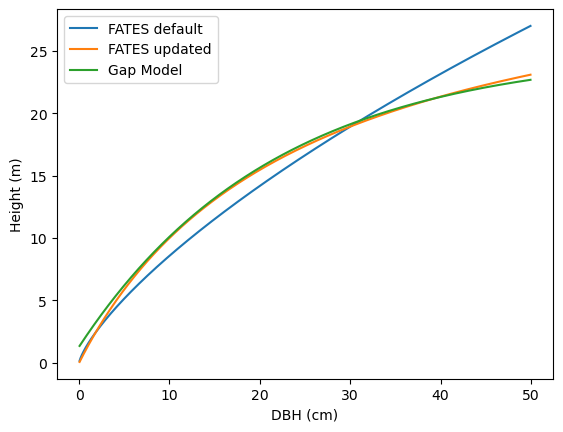

In [40]:
p1 = 34.69419
p2 = 0.98876
p3 = 24.06581
D = np.arange(0.05, 50, 0.05)
ht = (p1*D**p2)/(p3+D**p2)

p1_old = 306.842667
p2_old = 0.752377
p3_old = 196.6865691
ht_old = (p1_old*D**p2_old)/(p3_old+D**p2_old)

delta_ht = hmax - 1.3
forska_ht = 1.3 + delta_ht*(1.0 - np.exp(-(s*D/delta_ht)))

plt.plot(D, ht_old, label='FATES default')
plt.plot(D, ht, label='FATES updated')
plt.plot(D, forska_ht, label='Gap Model')
plt.legend(loc='upper left')
plt.xlabel('DBH (cm)')
plt.ylabel('Height (m)')